In [10]:
import numpy as np
import matplotlib.pyplot as plt

# dataset with two features (X1, X2) and one target (y)

# here are the 2 features
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6]
])

# and one label
y = np.array([3, 5, 7, 9, 11])

# number of samples
m = len(y)

# bias terms (m rows, 1 cols)
bias = np.ones((m, 1))

# insert bias terms at x_0
X_b = np.c_[bias, X]  

print("Feature Matrix (with bias):\n", X_b)
print("Target Values:\n", y)

Feature Matrix (with bias):
 [[1. 1. 2.]
 [1. 2. 3.]
 [1. 3. 4.]
 [1. 4. 5.]
 [1. 5. 6.]]
Target Values:
 [ 3  5  7  9 11]


In [15]:
# seed for reproducibility (remove when not needed)
np.random.seed(0)

# init params (theta) randomly (2 features, 1 bias)
theta = np.random.randn(3)  

# set hyperparameters
learning_rate = 0.01  # Step size for gradient descent
iterations = 1000  # Number of iterations to run gradient descent

# Print the initialized values
print(f"Initial theta values: {theta}")
print(f"Learning rate: {learning_rate}")
print(f"Number of iterations: {iterations}")

Initial theta values: [1.76405235 0.40015721 0.97873798]
Learning rate: 0.01
Number of iterations: 1000


In [18]:
def predict(X, theta):
    """Compute predictions h_theta(X) = X.dot(theta)"""
    return X.dot(theta)

def compute_cost(X, y, theta):
    """Compute the cost function J(theta)"""
    m = len(y)
    predictions = predict(X, theta)  # Use helper function
    errors = predictions - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

def gradient_descent_step(X, y, theta, learning_rate):
    """Perform one step of gradient descent"""
    m = len(y)
    predictions = predict(X, theta)  # Use helper function
    errors = predictions - y
    gradient = (1 / m) * X.T.dot(errors)  # Compute gradient
    theta = theta - learning_rate * gradient  # Update theta

    print(f"Cost: {compute_cost(X, y, theta)}")  # Print cost for reference
    print(f"Updated theta: {theta}")

    return theta


In [26]:
def run_gradient_descent(X, y, theta, learning_rate, iterations):
    """
    Run gradient descent until convergence.
    
    Parameters:
    X : numpy array
        Feature matrix (including bias term)
    y : numpy array
        Target values
    theta : numpy array
        Initial model parameters
    learning_rate : float
        Step size for gradient descent
    iterations : int
        Number of iterations to run gradient descent
    
    Returns:
    theta : numpy array
        Final parameters after all iterations
    """
    cost_history = []
    
    for i in range(iterations):
        theta = gradient_descent_step(X, y, theta, learning_rate)  # Perform one step
        cost_history.append(compute_cost(X, y, theta))
        
        print(f"Iteration {i+1}: Cost: {compute_cost(X, y, theta)} | Theta: {theta}")
    
    return theta, cost_history


In [27]:
# Hyperparameters
iterations = 1000
learning_rate = 0.01

# Run gradient descent
theta_final, cost_history = run_gradient_descent(X_b, y, theta, learning_rate, iterations)

# Final parameters
print(f"Final theta after {iterations} iterations: {theta_final}")


Cost: 0.345539464703099
Updated theta: [1.76525759 0.41619503 0.99598104]
Iteration 1: Cost: 0.345539464703099 | Theta: [1.76525759 0.41619503 0.99598104]
Cost: 0.3215221017393525
Updated theta: [1.76527992 0.4280185  1.00782685]
Iteration 2: Cost: 0.3215221017393525 | Theta: [1.76527992 0.4280185  1.00782685]
Cost: 0.30907738982047106
Updated theta: [1.76447349 0.43688231 1.01588423]
Iteration 3: Cost: 0.30907738982047106 | Theta: [1.76447349 0.43688231 1.01588423]
Cost: 0.30233839379901717
Updated theta: [1.76308692 0.44366726 1.02128261]
Iteration 4: Cost: 0.30233839379901717 | Theta: [1.76308692 0.44366726 1.02128261]
Cost: 0.29841374340063587
Updated theta: [1.76129473 0.44899169 1.02481484]
Iteration 5: Cost: 0.29841374340063587 | Theta: [1.76129473 0.44899169 1.02481484]
Cost: 0.29587849512073594
Updated theta: [1.75921943 0.45328968 1.02703755]
Iteration 6: Cost: 0.29587849512073594 | Theta: [1.75921943 0.45328968 1.02703755]
Cost: 0.2940303942960354
Updated theta: [1.75694705 

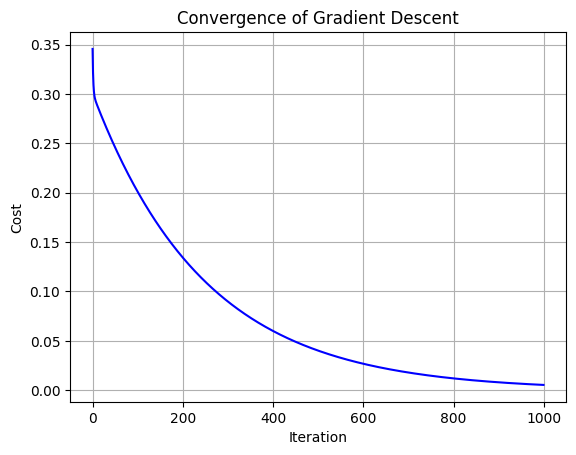

In [28]:
# Plot the cost function over iterations
plt.plot(range(iterations), cost_history, color='blue')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Convergence of Gradient Descent')
plt.grid(True)
plt.show()
